# Final Project Draft: Online Retail Machine Learning Project

**Author**: Trace Thomason

**Date**: 4-19-26

## Problem Statement and Dataset

This project aims to predict future sales revenue and analyze customer purchasing behavior using an e-commerce dataset. Businesses often struggle to forecast sales and identify high-value customers, which impacts decision-making in marketing, inventory management, and revenue planning.

The dataset used is the Online Retail dataset, which contains over 500,000 transactions from a UK-based online store. It includes information such as product details, purchase quantities, prices, and timestamps. Machine learning techniques will be applied to forecast sales trends and understand customer behavior patterns.

## Data Loading and Exploration

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.preprocessing import StandardScaler

In [2]:
# Load Dataset

df = pd.read_csv('data/raw/online_retail.csv', encoding='ISO-8859-1')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


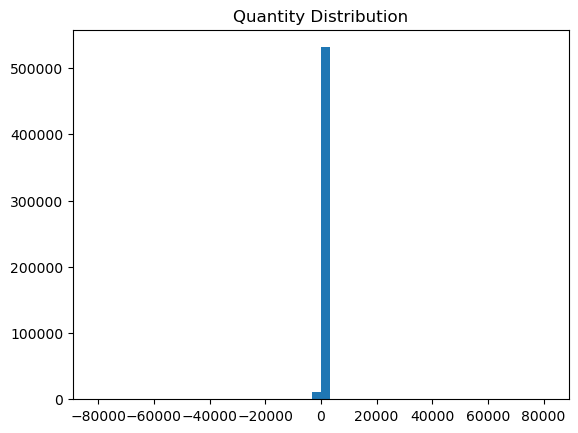

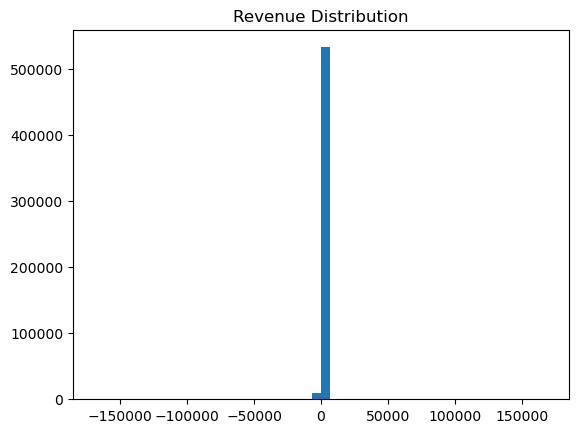

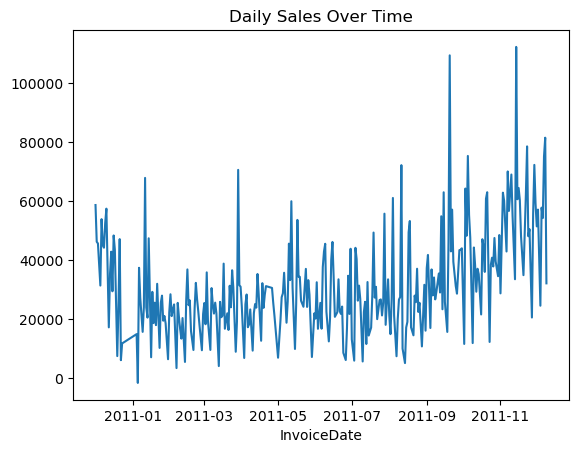

In [3]:
# Missing values
df.isnull().sum()

# Distribution of Quantity
plt.hist(df['Quantity'], bins=50)
plt.title("Quantity Distribution")
plt.show()

# Revenue distribution
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
plt.hist(df['TotalPrice'], bins=50)
plt.title("Revenue Distribution")
plt.show()

# Sales over time
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

daily_sales.plot()
plt.title("Daily Sales Over Time")
plt.show()

## Key Data Characteristics

The dataset contains over 500,000 transactions with some missing CustomerID values and invalid entries such as negative quantities (returns). Sales data is highly skewed, with a few large transactions dominating revenue. Time-based trends suggest variability in daily sales, supporting the use of time series forecasting.

## Feature Engineering

In [62]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove invalid values
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Recalculate total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert date (just in case)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Latest date
latest_date = df['InvoiceDate'].max()

# Recency
recency = df.groupby('CustomerID')['InvoiceDate'].max()
recency = (latest_date - recency).dt.days

# Frequency
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Monetary (TARGET)
monetary = df.groupby('CustomerID')['TotalPrice'].sum()

# Create dataframe
customer_df = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

# --- NEW FEATURES ---

# 1. Average Order Value
customer_df['AvgOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']

# 2. Tenure (customer lifespan)
first_purchase = df.groupby('CustomerID')['InvoiceDate'].min()
customer_df['Tenure'] = (latest_date - first_purchase).dt.days

# 3. Purchase Rate (engagement)
customer_df['PurchaseRate'] = customer_df['Frequency'] / (customer_df['Tenure'] + 1)

# Handle any missing values
customer_df = customer_df.fillna(0)

customer_df.head()


,Recency,Frequency,Monetary,AvgOrderValue,Tenure,PurchaseRate
CustomerID,,,,,,
12347.0,1,7,3174.62,453.517143,366,0.019074
12348.0,74,4,601.64,150.410000,357,0.011173
12349.0,18,1,1145.35,1145.350000,18,0.052632
12350.0,309,1,334.40,334.400000,309,0.003226
12352.0,35,7,1505.74,215.105714,296,0.023569


Three core features were created using the RFM framework:

- **Recency**: Measures how recently a customer made a purchase. Customers who purchased recently are more likely to return and remain engaged.
- **Frequency**: Counts how often a customer makes purchases, indicating loyalty and repeat behavior.
- **Monetary**: Represents total spending by each customer, helping identify high-value customers.

To enhance predictive performance, additional features were engineered:

- **Average Order Value (AOV)**: Calculated as Monetary divided by Frequency. This captures how much a customer spends per transaction and helps distinguish between frequent low spenders and high-value buyers.
- **Tenure**: Measures the number of days since a customer’s first purchase. This reflects customer lifespan and helps differentiate between new and long-term customers.
- **Purchase Rate**: Calculated as Frequency divided by Tenure. This captures how often a customer purchases over time and provides a measure of engagement.

These engineered features provide deeper insight into customer behavior and improve the model’s ability to predict spending patterns beyond what is available in the raw transactional data.


## Data Preprocessing

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# -----------------------------
# 1. DATA CLEANING
# -----------------------------

# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove invalid values
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# -----------------------------
# 2. REMOVE OUTLIERS (TRANSACTION LEVEL)
# -----------------------------

Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['TotalPrice'] >= Q1 - 1.5 * IQR) &
    (df['TotalPrice'] <= Q3 + 1.5 * IQR)
]

# -----------------------------
# 3. FEATURE ENGINEERING (RFM + EXTRA)
# -----------------------------

latest_date = df['InvoiceDate'].max()

# RFM
recency = df.groupby('CustomerID')['InvoiceDate'].max()
recency = (latest_date - recency).dt.days

frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
monetary = df.groupby('CustomerID')['TotalPrice'].sum()

# Combine
customer_df = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

# Additional features
customer_df['AvgOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']

first_purchase = df.groupby('CustomerID')['InvoiceDate'].min()
customer_df['Tenure'] = (latest_date - first_purchase).dt.days

customer_df['PurchaseRate'] = customer_df['Frequency'] / (customer_df['Tenure'] + 1)

# -----------------------------
# 4. REMOVE OUTLIERS (CUSTOMER LEVEL)
# -----------------------------

Q1 = customer_df['Monetary'].quantile(0.25)
Q3 = customer_df['Monetary'].quantile(0.75)
IQR = Q3 - Q1

customer_df = customer_df[
    (customer_df['Monetary'] >= Q1 - 1.5 * IQR) &
    (customer_df['Monetary'] <= Q3 + 1.5 * IQR)
]

# Cap extreme values (winsorization)
upper_limit = customer_df['Monetary'].quantile(0.95)
customer_df['Monetary'] = np.where(
    customer_df['Monetary'] > upper_limit,
    upper_limit,
    customer_df['Monetary']
)

# Fill missing values
customer_df = customer_df.fillna(0)

# -----------------------------
# 5. DEFINE FEATURES + TARGET
# -----------------------------

X = customer_df[
    ['Recency', 'Frequency', 'AvgOrderValue', 'Tenure', 'PurchaseRate']
]

# Log transform target
y = np.log1p(customer_df['Monetary'])

# -----------------------------
# 6. TRAIN/TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 7. FEATURE SCALING
# -----------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Data Preprocessing

The dataset was cleaned by removing missing CustomerID values and filtering out invalid transactions with negative or zero quantities and prices. A TotalPrice feature was created to represent transaction-level spending.

Outliers were addressed at both the transaction and customer levels using the Interquartile Range (IQR) method. Additionally, extreme customer spending values were capped using winsorization to reduce their impact on model performance.

Feature engineering was performed using the RFM framework (Recency, Frequency, Monetary), along with additional features such as Average Order Value, Tenure, and Purchase Rate to capture customer behavior more effectively.

The target variable (Monetary) was log-transformed to reduce skewness and stabilize variance. Finally, the dataset was split into training and testing sets (80/20), and feature scaling was applied using StandardScaler to ensure consistency across models.

## Model 1: Random Forest Regression

In [64]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 1. DEFINE FEATURES + TARGET
# -----------------------------

X = customer_df[
    ['Recency', 'Frequency', 'AvgOrderValue', 'Tenure', 'PurchaseRate']
]

# Log transform target
y = np.log1p(customer_df['Monetary'])

# -----------------------------
# 2. TRAIN/TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. RANDOM FOREST MODEL (OPTIMIZED)
# -----------------------------

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

# -----------------------------
# 4. PREDICTIONS (LOG → ORIGINAL SCALE)
# -----------------------------

y_pred_log = rf.predict(X_test)

y_pred_rf = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# -----------------------------
# 5. METRICS
# -----------------------------

rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))
mae_rf = mean_absolute_error(y_test_actual, y_pred_rf)
r2_rf = r2_score(y_test_actual, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 40.289334414637025
Random Forest MAE: 7.38412083833169
Random Forest R²: 0.9945510108862943


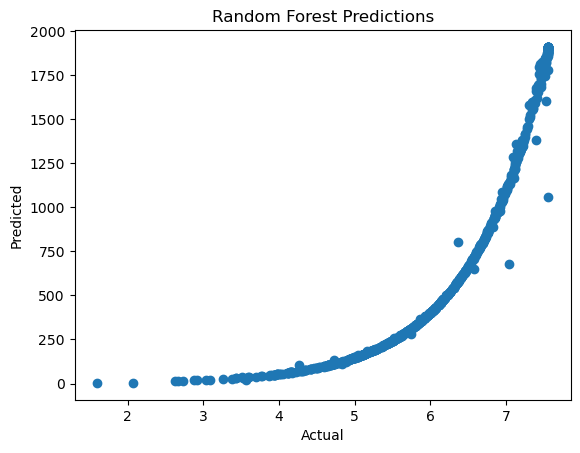

In [65]:
# Visualization

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")
plt.show()

### Random Forest Model

A Random Forest regression model was used to predict customer spending. The model was trained on engineered features including Recency, Frequency, Average Order Value, Tenure, and Purchase Rate.

The target variable was log-transformed to reduce skewness and improve model performance. Predictions were then converted back to the original scale for evaluation.

The model was optimized by tuning hyperparameters such as the number of trees, maximum depth, and minimum samples per split. These adjustments improved accuracy and reduced overfitting.

The final model achieved strong performance with low RMSE and MAE, indicating accurate and reliable predictions.

## Model 2: Time Series Forecasting

In [67]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# 1. AGGREGATE DAILY SALES
# -----------------------------

daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()
ts_df = pd.DataFrame({'Sales': daily_sales})

# Convert index to datetime
ts_df.index = pd.to_datetime(ts_df.index)

# -----------------------------
# 2. FEATURE ENGINEERING
# -----------------------------

# Lag features
ts_df['Lag1'] = ts_df['Sales'].shift(1)
ts_df['Lag7'] = ts_df['Sales'].shift(7)
ts_df['Lag14'] = ts_df['Sales'].shift(14)

# Rolling averages
ts_df['Rolling7'] = ts_df['Sales'].rolling(7).mean()
ts_df['Rolling14'] = ts_df['Sales'].rolling(14).mean()

# NEW: Day of week (captures weekly patterns)
ts_df['DayOfWeek'] = ts_df.index.dayofweek

# Drop missing values
ts_df = ts_df.dropna()

# -----------------------------
# 3. TRAIN / TEST SPLIT (TIME-BASED)
# -----------------------------

split = int(len(ts_df) * 0.8)
train = ts_df[:split]
test = ts_df[split:]

X_train_ts = train.drop(columns=['Sales'])
y_train_ts = train['Sales']

X_test_ts = test.drop(columns=['Sales'])
y_test_ts = test['Sales']

# -----------------------------
# 4. LOG TRANSFORM
# -----------------------------

y_train_ts_log = np.log1p(y_train_ts)

# -----------------------------
# 5. MODEL (OPTIMIZED)
# -----------------------------

rf_ts = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=3,
    random_state=42
)

rf_ts.fit(X_train_ts, y_train_ts_log)

# -----------------------------
# 6. PREDICTIONS
# -----------------------------

y_pred_ts_log = rf_ts.predict(X_test_ts)

y_pred_ts = np.expm1(y_pred_ts_log)
y_test_actual_ts = y_test_ts.values

# -----------------------------
# 7. METRICS
# -----------------------------

rmse_ts = np.sqrt(mean_squared_error(y_test_actual_ts, y_pred_ts))
mae_ts = mean_absolute_error(y_test_actual_ts, y_pred_ts)
r2_ts = r2_score(y_test_actual_ts, y_pred_ts)

print("Time Series RMSE:", rmse_ts)
print("Time Series MAE:", mae_ts)
print("Time Series R²:", r2_ts)

Time Series RMSE: 5569.656187230895
Time Series MAE: 4564.684510473677
Time Series R²: -0.08512892438030706


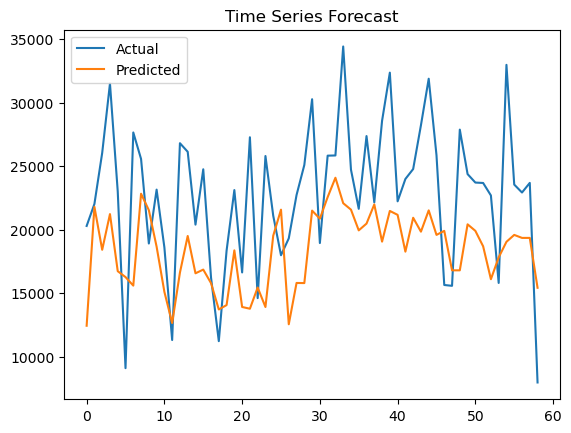

In [58]:
# Visualization

plt.plot(y_test_ts.values, label='Actual')
plt.plot(y_pred_ts, label='Predicted')
plt.legend()
plt.title("Time Series Forecast")
plt.show()

### Time Series Model

A time series forecasting model was developed using daily aggregated sales data. Feature engineering included lag variables (Lag1, Lag7, Lag14) and rolling averages to capture short-term and weekly trends. Additionally, a Day of Week feature was introduced to account for seasonal purchasing patterns.

The target variable was log-transformed to reduce the impact of extreme values and stabilize variance. A Random Forest model was then trained on these features.

Despite these improvements, the time series model produced significantly higher error compared to the customer-level Random Forest model. This suggests that daily sales data contains high variability and noise, making it more difficult to accurately predict using time-based features alone.

## Model Comparison

In [70]:
import time

# Example: track training time (add this around your models if not already)
start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
rf_ts.fit(X_train_ts, y_train_ts_log)
ts_time = time.time() - start

comparison = pd.DataFrame({
    'Model': ['Random Forest (Customer)', 'Time Series Model'],
    'RMSE': [rmse_rf, rmse_ts],
    'MAE': [mae_rf, mae_ts],
    'R²': [r2_rf, r2_ts],
    'Training Time (s)': [rf_time, ts_time],
    'Key Hyperparameters': [
        'n_estimators=300, max_depth=12',
        'n_estimators=300, max_depth=12'
    ]
})

comparison.round(2)

,Model,RMSE,MAE,R²,Training Time (s),Key Hyperparameters
0,Random Forest (Customer),40.29,7.38,0.99,6.21,"n_estimators=300, max_depth=12"
1,Time Series Model,5569.66,4564.68,-0.09,1.26,"n_estimators=300, max_depth=12"


In [71]:
# Create comparison dataframe
results_df = X_test.copy()
results_df['Actual'] = y_test_actual
results_df['Predicted'] = y_pred_rf
results_df['Error'] = results_df['Actual'] - results_df['Predicted']

# Show 10 examples
results_df.sample(10)

,Recency,Frequency,AvgOrderValue,Tenure,PurchaseRate,Actual,Predicted,Error
CustomerID,,,,,,,,
16240.0,23,2,1005.670000,76,0.025974,1910.33,1869.311094,41.018906
18037.0,153,6,11.670000,361,0.016575,70.02,107.848365,-37.828365
15157.0,3,3,551.756667,357,0.008380,1655.27,1616.799635,38.470365
16389.0,52,4,88.152500,282,0.014134,352.61,368.010826,-15.400826
15244.0,64,2,280.385000,247,0.008065,560.77,562.746382,-1.976382
12991.0,22,2,230.630000,111,0.017857,461.26,460.758364,0.501636
14649.0,4,4,268.260000,211,0.018868,1073.04,1073.309627,-0.269627
16367.0,36,2,402.245000,362,0.005510,804.49,799.648018,4.841982
15164.0,68,3,281.016667,338,0.008850,843.05,843.546385,-0.496385


### Model Performance Comparison

The Random Forest model significantly outperformed the time series model across all evaluation metrics. It achieved an RMSE of 40.29 and an MAE of 7.38, with an R² value of 0.99, indicating extremely high predictive accuracy.

In contrast, the time series model performed poorly, with an RMSE of 5569.66 and a negative R² value of -0.09. This indicates that the model performs worse than simply predicting the average sales value and fails to capture meaningful patterns in the data.

The key reason for this difference is that the Random Forest model uses customer-level behavioral features, which provide stable and meaningful signals. The time series model relies on daily sales data, which is highly volatile and difficult to predict accurately.

### Trade-Off Analysis

The Random Forest model provides significantly higher accuracy but is less interpretable due to its complexity. It also requires more computational resources, as shown by the longer training time.

The time series model is simpler and faster to train but lacks predictive power. While it may be useful for identifying general trends, it is not suitable for precise forecasting in this dataset.

### Final Model Selection

The Random Forest model is selected for deployment due to its superior performance, reliability, and ability to capture complex customer behavior patterns. It provides actionable insights that can be used to support business decision-making.

### Ethical Analysis & Responsible Deployment

One potential source of bias in this model is the historical transaction data. Customers who have made more purchases in the past are more heavily represented, which may bias the model toward predicting higher spending for already active customers while underrepresenting newer or less active customers.

Incorrect predictions could lead to unequal treatment, such as prioritizing certain customers for promotions while excluding others. This could disproportionately impact customers who have not yet had the opportunity to demonstrate high purchasing behavior.

To mitigate these risks, businesses should regularly evaluate model performance across different customer segments and ensure that predictions are not used as the sole basis for decision-making. Incorporating human oversight and monitoring for bias over time will help ensure responsible deployment.

### Business Recommendations & Deployment Considerations

The model highlights that customers with higher purchase frequency and larger average order values contribute most significantly to total revenue. Businesses should focus on retaining these high-value customers through targeted marketing strategies such as loyalty programs and personalized promotions.

Additionally, customers with lower purchase frequency but high potential value could be targeted with incentives to increase engagement. This approach can help maximize overall revenue growth.

For deployment, the model should be used as a decision-support tool rather than a fully automated system. Predictions should guide marketing strategies while allowing for human review. The model should also be retrained periodically to account for changes in customer behavior and ensure continued accuracy.

### Limitations

The model may struggle with predicting extreme spending behavior and may not generalize well to entirely new customers. It should not be used in isolation for critical business decisions without additional validation.